##  Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Plot style

In [2]:
plt.rcParams.update({
    'figure.facecolor': '#F8FAFC',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E2E8F0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.size':        11,
})
PALETTE = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED','#0891B2','#BE185D']
sns.set_palette(PALETTE)

print(' Libraries loaded successfully')
print(f'   NumPy  version: {np.__version__}')
print(f'   Pandas version: {pd.__version__}')

 Libraries loaded successfully
   NumPy  version: 2.3.3
   Pandas version: 2.3.3


In [3]:
import seaborn as sns

PALETTE = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED','#0891B2','#BE185D']
sns.set_palette(PALETTE)

## Load the Dataset

In [4]:
df = pd.read_csv("C:\\Users\\Sanket\\Downloads\\github\\sales\\retail_sales.csv", parse_dates=['date'])
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Shape : 2,000 rows × 13 columns
Memory: 771.8 KB


,order_id,date,customer_id,customer_age,gender,city,category,unit_price,quantity,discount_pct,total_amount,payment_method,rating
0,ORD00001,2023-01-01 00:00:00.000000,CUST2373,43,Female,Hyderabad,Home & Garden,163.99,1,5,155.79,UPI,1
1,ORD00002,2023-01-01 08:45:51.775887,CUST2223,24,Female,Bangalore,Clothing,2234.21,1,0,2234.21,Net Banking,5
2,ORD00003,2023-01-01 17:31:43.551775,CUST2959,24,Female,Kolkata,Sports,843.68,1,0,843.68,UPI,3
3,ORD00004,2023-01-02 02:17:35.327663,CUST4757,25,Male,Bangalore,Electronics,924.54,3,20,2218.90,UPI,4
4,ORD00005,2023-01-02 11:03:27.103551,CUST4014,33,Male,Hyderabad,Beauty,123.66,1,0,123.66,Cash,3


## First Look — Shape, Types, Sample

In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        2000 non-null   object        
 1   date            2000 non-null   datetime64[ns]
 2   customer_id     2000 non-null   object        
 3   customer_age    2000 non-null   int64         
 4   gender          2000 non-null   object        
 5   city            2000 non-null   object        
 6   category        2000 non-null   object        
 7   unit_price      2000 non-null   float64       
 8   quantity        2000 non-null   int64         
 9   discount_pct    2000 non-null   int64         
 10  total_amount    2000 non-null   float64       
 11  payment_method  2000 non-null   object        
 12  rating          2000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 203.3+ KB


In [6]:
# Statistical summary
df.describe().round(2)

,date,customer_age,unit_price,quantity,discount_pct,total_amount,rating
count,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2023-12-31 23:59:59.999999488,41.08,925.29,1.34,4.90,1181.91,3.81
min,2023-01-01 00:00:00,18.00,50.83,1.00,0.00,49.39,1.00
25%,2023-07-02 11:59:59.999999232,30.00,414.06,1.00,0.00,457.51,3.00
50%,2023-12-31 23:59:59.999999488,41.00,738.68,1.00,5.00,857.02,4.00
75%,2024-07-01 11:59:59.999999744,53.00,1319.10,1.25,10.00,1534.16,5.00
max,2024-12-31 00:00:00,64.00,2998.74,4.00,20.00,8220.48,5.00
std,NaN,13.41,646.72,0.67,5.79,1081.16,1.12


In [7]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '  ✅ No missing values found!')

dupes = df.duplicated('order_id').sum()
print(f'Duplicate order_ids : {dupes}')
print(f'Unique customers    : {df["customer_id"].nunique():,}')
print(f'Date range          : {df["date"].min().date()} → {df["date"].max().date()}')

Missing values per column:
  ✅ No missing values found!
Duplicate order_ids : 0
Unique customers    : 1,578
Date range          : 2023-01-01 → 2024-12-31


## NumPy — Core Statistical Analysis

Using NumPy directly on arrays to compute descriptive stats, percentiles, and correlations.

In [8]:
amounts = df['total_amount'].values  # pure numpy array

print('=' * 46)
print('  REVENUE STATISTICS  (NumPy)')
print('=' * 46)
print(f'  Total Revenue   : ₹{np.sum(amounts):>13,.0f}')
print(f'  Mean Order      : ₹{np.mean(amounts):>13,.2f}')
print(f'  Median Order    : ₹{np.median(amounts):>13,.2f}')
print(f'  Std Deviation   : ₹{np.std(amounts):>13,.2f}')
print(f'  Min / Max       : ₹{np.min(amounts):,.0f}  /  ₹{np.max(amounts):,.0f}')
print(f'  Skewness (manual): {((np.mean(amounts)-np.median(amounts))/np.std(amounts)):.4f}')
print()
print('  REVENUE PERCENTILES')
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(amounts, p)
    print(f'  P{p:<3}            : ₹{val:>13,.2f}')

  REVENUE STATISTICS  (NumPy)
  Total Revenue   : ₹    2,363,826
  Mean Order      : ₹     1,181.91
  Median Order    : ₹       857.02
  Std Deviation   : ₹     1,080.89
  Min / Max       : ₹49  /  ₹8,220
  Skewness (manual): 0.3006

  REVENUE PERCENTILES
  P10             : ₹       255.90
  P25             : ₹       457.51
  P50             : ₹       857.02
  P75             : ₹     1,534.16
  P90             : ₹     2,431.00
  P95             : ₹     3,332.49
  P99             : ₹     5,369.79


In [9]:
# Customer age analysis with NumPy
ages = df['customer_age'].values

print('CUSTOMER AGE — NumPy Statistics')
print(f'  Mean   : {np.mean(ages):.1f} years')
print(f'  Median : {np.median(ages):.1f} years')
print(f'  Std    : {np.std(ages):.1f} years')
print(f'  Range  : {np.min(ages)} – {np.max(ages)} years')

# Age buckets with np.digitize
bins   = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
idx    = np.clip(np.digitize(ages, bins) - 1, 0, len(labels)-1)

print('\nAGE GROUP DISTRIBUTION')
for i, lbl in enumerate(labels):
    count = int(np.sum(idx == i))
    bar   = '█' * (count // 15)
    print(f'  {lbl}: {count:>4} customers  {bar}')

CUSTOMER AGE — NumPy Statistics
  Mean   : 41.1 years
  Median : 41.0 years
  Std    : 13.4 years
  Range  : 18 – 64 years

AGE GROUP DISTRIBUTION
  18-24:  276 customers  ██████████████████
  25-34:  443 customers  █████████████████████████████
  35-44:  454 customers  ██████████████████████████████
  45-54:  391 customers  ██████████████████████████
  55-64:  436 customers  █████████████████████████████


In [10]:
# Correlation matrix using NumPy corrcoef
num_cols = ['customer_age','unit_price','quantity','discount_pct','total_amount','rating']
matrix   = df[num_cols].values.astype(float)
corr     = np.corrcoef(matrix.T)

print('PEARSON CORRELATION MATRIX  (NumPy)')
header = ''.join(f'{c[:8]:>10}' for c in num_cols)
print(f'  {"":<14}{header}')
for i, col in enumerate(num_cols):
    row_str = ''.join(f'{corr[i,j]:>10.3f}' for j in range(len(num_cols)))
    print(f'  {col:<15}{row_str}')

PEARSON CORRELATION MATRIX  (NumPy)
                  customer  unit_pri  quantity  discount  total_am    rating
  customer_age        1.000     0.004     0.008    -0.005     0.011    -0.060
  unit_price          0.004     1.000     0.001     0.010     0.757    -0.051
  quantity            0.008     0.001     1.000    -0.020     0.538     0.015
  discount_pct       -0.005     0.010    -0.020     1.000    -0.073     0.001
  total_amount        0.011     0.757     0.538    -0.073     1.000    -0.030
  rating             -0.060    -0.051     0.015     0.001    -0.030     1.000


## Pandas — Exploratory Data Analysis

## Revenue by Category

In [11]:
cat_stats = df.groupby('category').agg(
    orders       = ('order_id',     'count'),
    revenue      = ('total_amount', 'sum'),
    avg_order    = ('total_amount', 'mean'),
    avg_discount = ('discount_pct', 'mean'),
    avg_rating   = ('rating',       'mean'),
    total_qty    = ('quantity',     'sum'),
).round(2).sort_values('revenue', ascending=False)

cat_stats['revenue_share_%'] = (cat_stats['revenue'] / cat_stats['revenue'].sum() * 100).round(1)
cat_stats

,orders,revenue,avg_order,avg_discount,avg_rating,total_qty,revenue_share_%
category,,,,,,,
Clothing,357,650008.51,1820.75,4.69,3.81,478,27.5
Sports,271,516728.46,1906.75,5.20,3.80,371,21.9
Electronics,396,408984.94,1032.79,5.13,3.76,529,17.3
Home & Garden,286,384431.75,1344.17,4.77,3.78,379,16.3
Food & Beverage,308,168944.53,548.52,4.74,3.78,405,7.1
Beauty,162,136217.51,840.85,4.91,3.92,219,5.8
Books,220,98509.81,447.77,4.84,3.90,303,4.2


## Monthly Revenue Trend

In [12]:
df['month'] = df['date'].dt.to_period('M')

monthly = df.groupby('month').agg(
    revenue = ('total_amount', 'sum'),
    orders  = ('order_id',     'count'),
).reset_index()
monthly['aov']         = (monthly['revenue'] / monthly['orders']).round(2)
monthly['mom_growth_%']= monthly['revenue'].pct_change().mul(100).round(1)
monthly['month']       = monthly['month'].astype(str)
monthly.tail(8)

,month,revenue,orders,aov,mom_growth_%
16,2024-05,95285.19,85,1121.00,-9.4
17,2024-06,100287.81,82,1223.02,5.3
18,2024-07,110466.84,85,1299.61,10.1
19,2024-08,109982.14,85,1293.91,-0.4
20,2024-09,88706.83,82,1081.79,-19.3
21,2024-10,116437.36,85,1369.85,31.3
22,2024-11,84671.06,82,1032.57,-27.3
23,2024-12,114293.27,83,1377.03,35.0


## City Performance

In [13]:
city_stats = df.groupby('city').agg(
    revenue      = ('total_amount', 'sum'),
    orders       = ('order_id',     'count'),
    unique_custs = ('customer_id',  'nunique'),
    avg_rating   = ('rating',       'mean'),
).round(2).sort_values('revenue', ascending=False)

city_stats['revenue_share_%']  = (city_stats['revenue'] / city_stats['revenue'].sum() * 100).round(1)
city_stats['revenue_per_cust'] = (city_stats['revenue'] / city_stats['unique_custs']).round(2)
city_stats

,revenue,orders,unique_custs,avg_rating,revenue_share_%,revenue_per_cust
city,,,,,,
Mumbai,392644.75,317,304,3.83,16.6,1291.59
Pune,357199.31,287,280,3.75,15.1,1275.71
Chennai,344001.63,286,276,3.79,14.6,1246.38
Kolkata,329868.11,296,280,3.97,14.0,1178.10
Bangalore,315660.77,272,265,3.86,13.4,1191.17
Delhi,312411.87,279,268,3.77,13.2,1165.72
Hyderabad,312039.07,263,253,3.67,13.2,1233.36


## Gender & Age Group Analysis

In [14]:
gender_rev = df.groupby('gender')['total_amount'].agg(['sum','mean','count']).round(2)
gender_rev.columns = ['total_revenue','avg_order','num_orders']
print('GENDER BREAKDOWN'); print(gender_rev)

df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[17,24,34,44,54,64],
    labels=['18-24','25-34','35-44','45-54','55-64']
)
age_grp = df.groupby('age_group', observed=True).agg(
    revenue   = ('total_amount','sum'),
    orders    = ('order_id','count'),
    avg_spend = ('total_amount','mean'),
).round(2).reset_index()
print('\nAGE GROUP BREAKDOWN'); print(age_grp.to_string(index=False))

GENDER BREAKDOWN
        total_revenue  avg_order  num_orders
gender                                      
Female     1201518.60    1209.99         993
Male       1162306.91    1154.23        1007

AGE GROUP BREAKDOWN
age_group   revenue  orders  avg_spend
    18-24 319659.15     276    1158.19
    25-34 508463.50     443    1147.77
    35-44 533300.84     454    1174.67
    45-54 494897.95     391    1265.72
    55-64 507504.07     436    1164.00


## Discount Impact Analysis

In [15]:
df['discount_bin'] = pd.cut(
    df['discount_pct'],
    bins=[-1,0,5,10,15,25],
    labels=['No Discount','1-5%','6-10%','11-15%','16-25%']
)
disc = df.groupby('discount_bin', observed=True).agg(
    orders     = ('order_id',     'count'),
    avg_amount = ('total_amount', 'mean'),
    avg_qty    = ('quantity',     'mean'),
    avg_rating = ('rating',       'mean'),
).round(2).reset_index()
disc

,discount_bin,orders,avg_amount,avg_qty,avg_rating
0,No Discount,934,1247.61,1.35,3.79
1,1-5%,521,1200.10,1.34,3.85
2,6-10%,275,1041.92,1.33,3.81
3,11-15%,191,1105.45,1.30,3.81
4,16-25%,79,957.44,1.33,3.75


## Payment Method Mix

In [16]:
pay = df.groupby('payment_method').agg(
    orders    = ('order_id',     'count'),
    revenue   = ('total_amount', 'sum'),
    avg_order = ('total_amount', 'mean'),
).sort_values('revenue', ascending=False).round(2)
pay['order_share_%']   = (pay['orders']  / pay['orders'].sum()  * 100).round(1)
pay['revenue_share_%'] = (pay['revenue'] / pay['revenue'].sum() * 100).round(1)
pay

,orders,revenue,avg_order,order_share_%,revenue_share_%
payment_method,,,,,
Credit Card,441,503385.66,1141.46,22.0,21.3
Debit Card,392,487569.66,1243.80,19.6,20.6
UPI,416,465205.68,1118.28,20.8,19.7
Net Banking,366,459381.12,1255.14,18.3,19.4
Cash,385,448283.39,1164.37,19.2,19.0


## Top 10 Customers by Revenue

In [17]:
top_custs = (
    df.groupby('customer_id')
    .agg(
        total_revenue = ('total_amount', 'sum'),
        num_orders    = ('order_id',     'count'),
        avg_rating    = ('rating',       'mean'),
        last_order    = ('date',         'max'),
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)
top_custs

,customer_id,total_revenue,num_orders,avg_rating,last_order
0,CUST2431,9409.92,2,4.5,2024-08-21 04:03:28.904452
1,CUST3330,9293.54,2,4.5,2024-10-16 09:46:22.391195
2,CUST4500,8678.02,2,4.0,2024-03-22 23:36:13.686843
3,CUST2359,8220.48,1,4.0,2024-10-07 15:25:39.769884
4,CUST3833,8015.11,1,1.0,2023-03-06 15:17:44.332166
5,CUST3960,7962.40,2,4.5,2024-10-26 15:10:32.116058
6,CUST2333,7841.68,3,4.0,2023-11-10 16:36:15.487743
7,CUST2841,7604.02,3,4.0,2024-07-24 18:43:45.712856
8,CUST3918,7384.84,2,5.0,2024-05-16 18:15:40.070035
9,CUST1707,7207.64,2,4.5,2023-03-10 15:42:13.866933


# Data Visualisations

## Monthly Revenue Trend

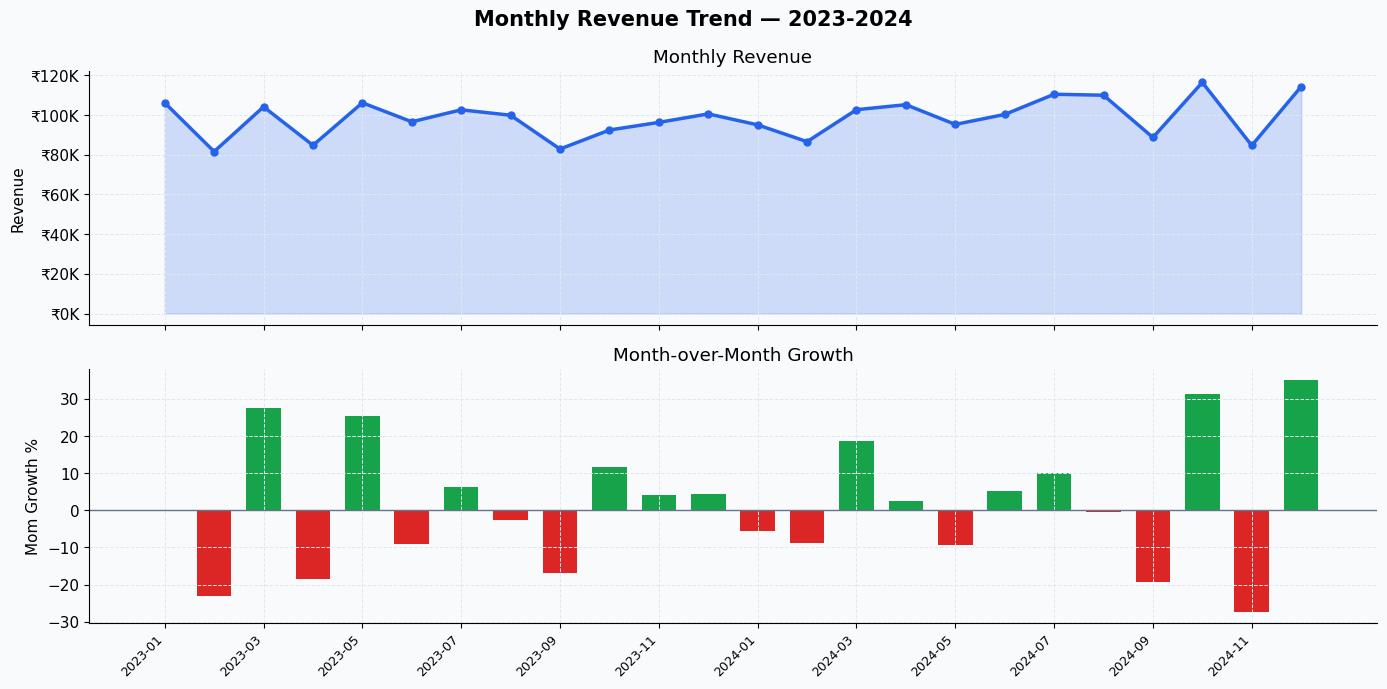

✓ Saved: monthly_revenue.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Monthly Revenue Trend — 2023-2024', fontsize=15, fontweight='bold')

x   = range(len(monthly))
rev = monthly['revenue']

axes[0].fill_between(x, rev, alpha=0.2, color='#2563EB')
axes[0].plot(x, rev, color='#2563EB', linewidth=2.5, marker='o', markersize=5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e3:.0f}K'))
axes[0].set_ylabel('Revenue')
axes[0].set_title('Monthly Revenue')

growth = monthly['mom_growth_%'].fillna(0)
colors = ['#16A34A' if v >= 0 else '#DC2626' for v in growth]
axes[1].bar(x, growth, color=colors, width=0.7)
axes[1].axhline(0, color='#64748B', linewidth=1)
axes[1].set_ylabel('Mom Growth %')
axes[1].set_xticks(list(x)[::2])
axes[1].set_xticklabels(monthly['month'].iloc[::2], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Month-over-Month Growth')

plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: monthly_revenue.png')

## Category Revenue & Rating Bubble

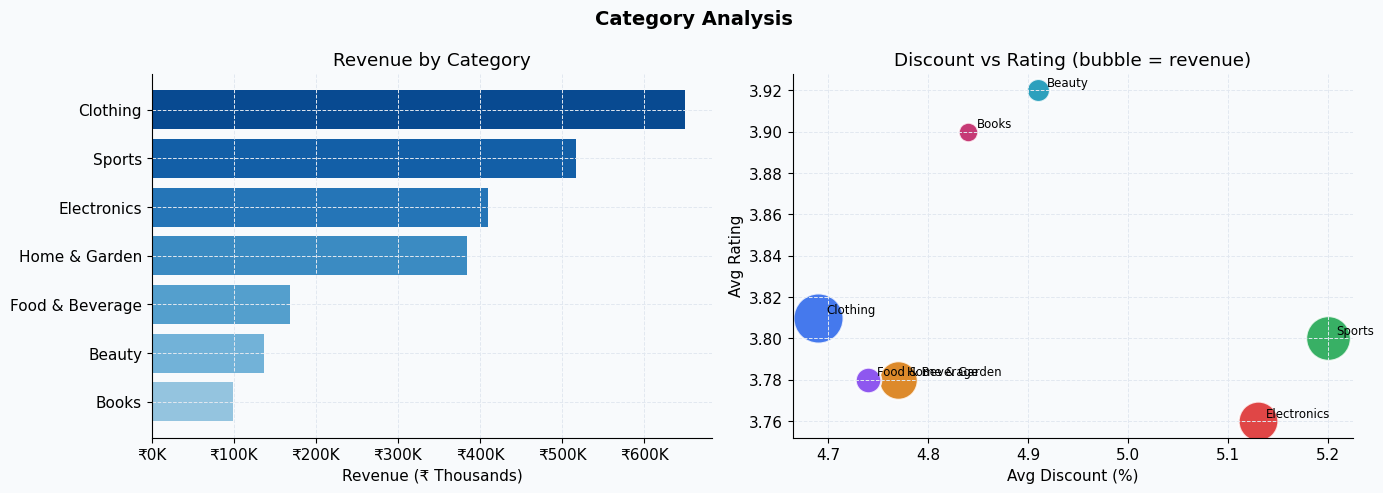

✓ Saved: category_analysis.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Analysis', fontsize=14, fontweight='bold')

cat_plot = cat_stats.reset_index().sort_values('revenue')
colors   = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_plot)))
axes[0].barh(cat_plot['category'], cat_plot['revenue']/1000, color=colors)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}K'))
axes[0].set_xlabel('Revenue (₹ Thousands)')
axes[0].set_title('Revenue by Category')

for i, (cat, row) in enumerate(cat_stats.iterrows()):
    axes[1].scatter(row['avg_discount'], row['avg_rating'],
                   s=row['revenue']/500, c=[PALETTE[i % len(PALETTE)]],
                   alpha=0.85, edgecolors='white', linewidth=1.5)
    axes[1].annotate(cat, (row['avg_discount'], row['avg_rating']),
                     textcoords='offset points', xytext=(6,3), fontsize=8.5)
axes[1].set_xlabel('Avg Discount (%)')
axes[1].set_ylabel('Avg Rating')
axes[1].set_title('Discount vs Rating (bubble = revenue)')

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: category_analysis.png')

## City Revenue & Payment Method

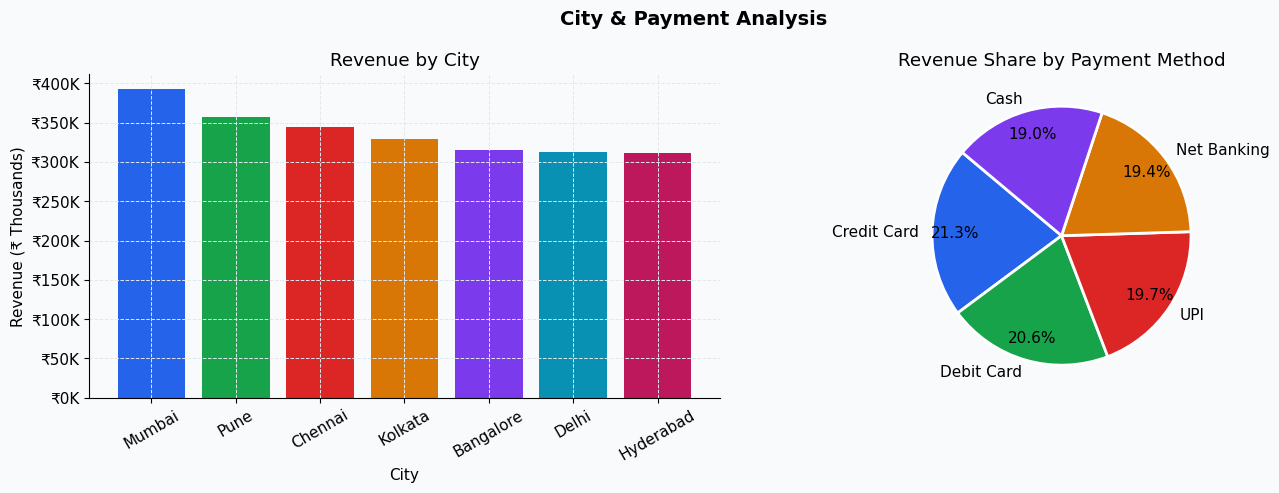

✓ Saved: city_payment.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('City & Payment Analysis', fontsize=14, fontweight='bold')

cities_sorted = city_stats.reset_index().sort_values('revenue', ascending=False)
axes[0].bar(cities_sorted['city'], cities_sorted['revenue']/1000,
            color=PALETTE[:len(cities_sorted)])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:.0f}K'))
axes[0].set_xlabel('City'); axes[0].set_ylabel('Revenue (₹ Thousands)')
axes[0].set_title('Revenue by City')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(pay['revenue'], labels=pay.index, autopct='%1.1f%%',
            colors=PALETTE[:len(pay)], startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Revenue Share by Payment Method')

plt.tight_layout()
plt.savefig('city_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: city_payment.png')

## Customer Demographics

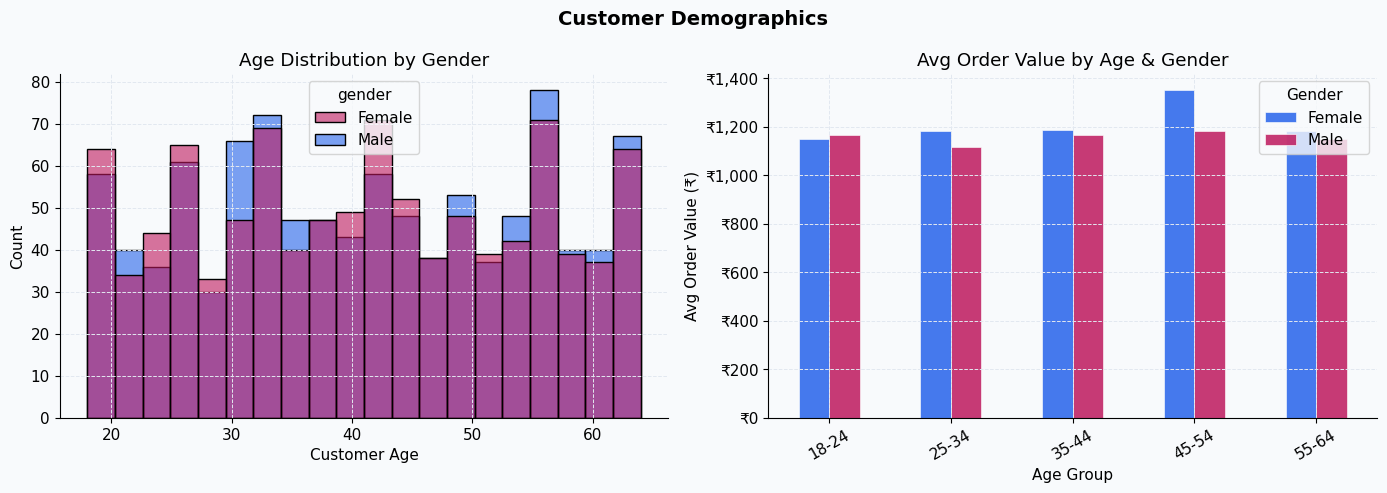

✓ Saved: demographics.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Demographics', fontsize=14, fontweight='bold')

sns.histplot(data=df, x='customer_age', hue='gender', bins=20,
             multiple='layer', alpha=0.6,
             palette={'Male':'#2563EB','Female':'#BE185D'}, ax=axes[0])
axes[0].set_xlabel('Customer Age'); axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Gender')

age_gender = df.groupby(['age_group','gender'], observed=True)['total_amount'].mean().unstack()
age_gender.plot(kind='bar', ax=axes[1],
                color=['#2563EB','#BE185D'], alpha=0.85,
                edgecolor='white', linewidth=0.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:,.0f}'))
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Avg Order Value (₹)')
axes[1].set_title('Avg Order Value by Age & Gender')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: demographics.png')

## Correlation Heatmap

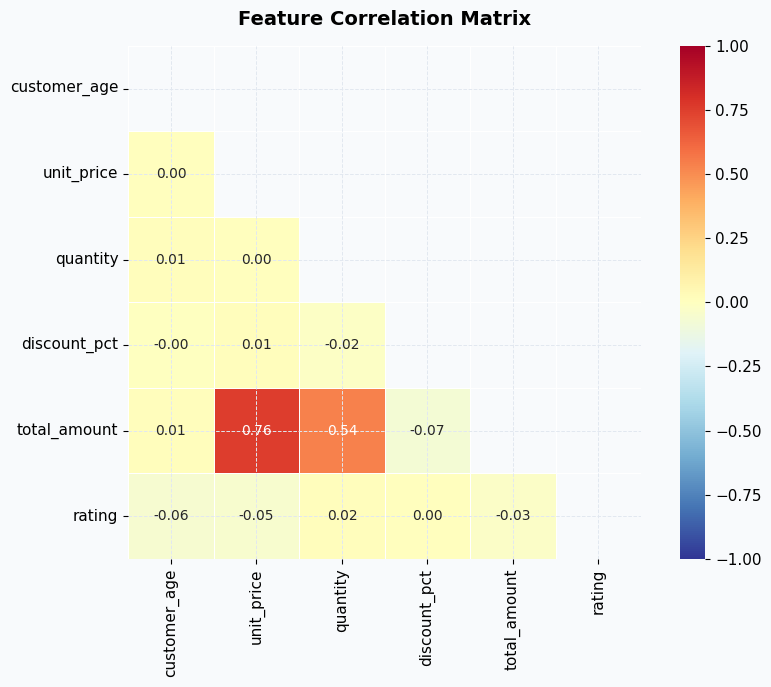

✓ Saved: correlation_heatmap.png


In [22]:
num_cols    = ['customer_age','unit_price','quantity','discount_pct','total_amount','rating']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white',
            annot_kws={'size':10}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: correlation_heatmap.png')

## Rating Distribution by Category

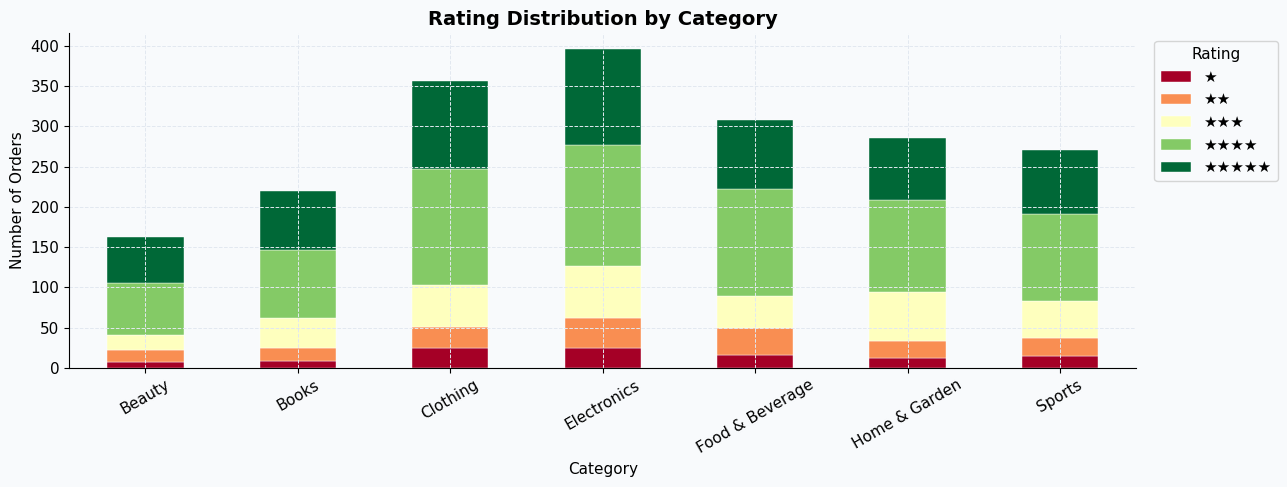

✓ Saved: ratings.png


In [23]:
fig, ax = plt.subplots(figsize=(13, 5))
rating_ct = df.groupby(['category','rating']).size().unstack(fill_value=0)
rating_ct.plot(kind='bar', stacked=True, ax=ax,
               colormap='RdYlGn', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Category'); ax.set_ylabel('Number of Orders')
ax.set_title('Rating Distribution by Category', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Rating', labels=['★','★★','★★★','★★★★','★★★★★'],
          bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: ratings.png')

## Discount Impact on Key Metrics

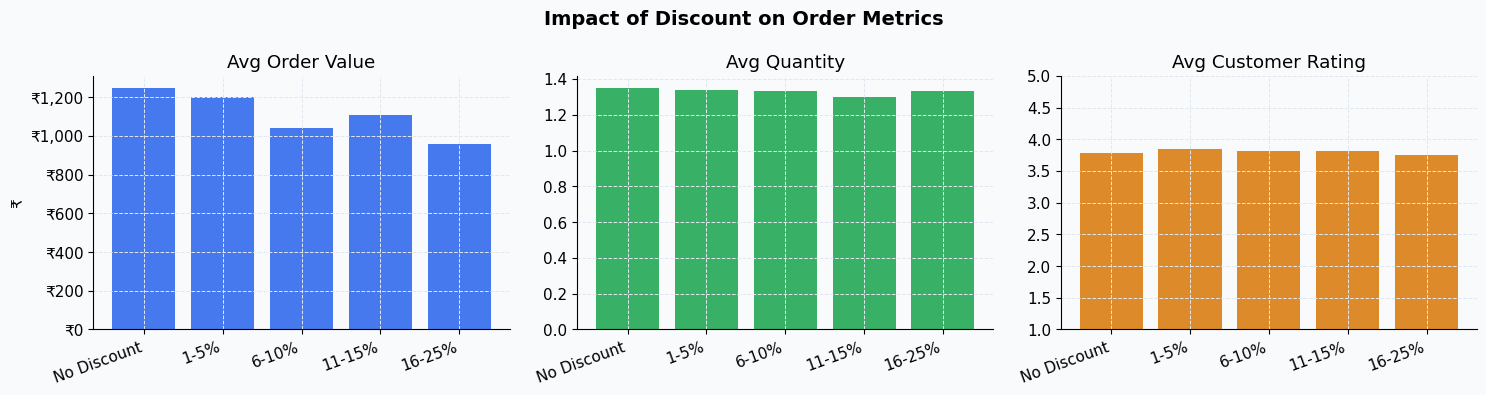

✓ Saved: discount_impact.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Impact of Discount on Order Metrics', fontsize=14, fontweight='bold')

bins_lbl = disc['discount_bin'].astype(str)
idx      = range(len(bins_lbl))

axes[0].bar(idx, disc['avg_amount'], color='#2563EB', alpha=0.85)
axes[0].set_xticks(list(idx)); axes[0].set_xticklabels(bins_lbl, rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:,.0f}'))
axes[0].set_title('Avg Order Value'); axes[0].set_ylabel('₹')

axes[1].bar(idx, disc['avg_qty'], color='#16A34A', alpha=0.85)
axes[1].set_xticks(list(idx)); axes[1].set_xticklabels(bins_lbl, rotation=20, ha='right')
axes[1].set_title('Avg Quantity')

bar_colors = ['#16A34A' if v >= 4 else '#D97706' if v >= 3 else '#DC2626' for v in disc['avg_rating']]
axes[2].bar(idx, disc['avg_rating'], color=bar_colors, alpha=0.85)
axes[2].set_xticks(list(idx)); axes[2].set_xticklabels(bins_lbl, rotation=20, ha='right')
axes[2].set_ylim(1, 5); axes[2].set_title('Avg Customer Rating')

plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: discount_impact.png')

## Key Business Insights

In [25]:
print('=' * 56)
print('   EXECUTIVE SUMMARY — RETAIL SALES 2023-2024')
print('=' * 56)

total_rev  = df['total_amount'].sum()
total_ord  = len(df)
uniq_custs = df['customer_id'].nunique()
aov        = df['total_amount'].mean()
avg_rating = df['rating'].mean()
best_cat   = cat_stats['revenue'].idxmax()
best_city  = city_stats['revenue'].idxmax()
best_pay   = pay['revenue'].idxmax()

print(f'  Total Revenue    : ₹{total_rev:>13,.0f}')
print(f'  Total Orders     : {total_ord:>14,}')
print(f'  Unique Customers : {uniq_custs:>14,}')
print(f'  Avg Order Value  : ₹{aov:>13,.2f}')
print(f'  Avg Rating       : {avg_rating:>14.2f} / 5')
print()
print(f'  🏆 Best Category : {best_cat}')
print(f'  🏆 Best City     : {best_city}')
print(f'  🏆 Best Payment  : {best_pay}')
print()

# NumPy 80/20 analysis
sorted_rev = np.sort(df['total_amount'].values)[::-1]
cumsum     = np.cumsum(sorted_rev)
top20_idx  = int(len(sorted_rev) * 0.20)
top20_pct  = cumsum[top20_idx] / cumsum[-1] * 100
print(f'  📊 Top 20% of orders → {top20_pct:.1f}% of revenue  (Pareto)')

# Peak month
peak       = monthly.loc[monthly['revenue'].idxmax()]
print(f'  📅 Peak Month    : {peak["month"]} (₹{peak["revenue"]:,.0f})')

# Repeat customers
repeat_pct = (df.groupby('customer_id').size() > 1).mean() * 100
print(f'  🔁 Repeat Customer  : {repeat_pct:.1f}% of customer base')

   EXECUTIVE SUMMARY — RETAIL SALES 2023-2024
  Total Revenue    : ₹    2,363,826
  Total Orders     :          2,000
  Unique Customers :          1,578
  Avg Order Value  : ₹     1,181.91
  Avg Rating       :           3.81 / 5

  🏆 Best Category : Clothing
  🏆 Best City     : Mumbai
  🏆 Best Payment  : Credit Card

  📊 Top 20% of orders → 48.8% of revenue  (Pareto)
  📅 Peak Month    : 2024-10 (₹116,437)
  🔁 Repeat Customer  : 22.5% of customer base


## Export Summary Report to Excel

In [26]:
with pd.ExcelWriter('sales_summary_report.xlsx', engine='openpyxl') as writer:
    cat_stats.reset_index().to_excel(writer, sheet_name='Category',     index=False)
    city_stats.reset_index().to_excel(writer, sheet_name='City',        index=False)
    monthly.to_excel(writer,           sheet_name='Monthly',            index=False)
    pay.reset_index().to_excel(writer, sheet_name='Payment',            index=False)
    top_custs.to_excel(writer,         sheet_name='Top_Customers',      index=False)
    disc.to_excel(writer,              sheet_name='Discount_Impact',    index=False)

print('✅ sales_summary_report.xlsx saved')
print()
print('ALL PROJECT FILES:')
import os
for f in sorted(os.listdir('.')):
    if f.endswith(('.png','.xlsx','.csv','.ipynb','.md','.gitignore','.txt')):
        size = os.path.getsize(f) // 1024
        print(f'  📄 {f:<42} ({size} KB)')

✅ sales_summary_report.xlsx saved

ALL PROJECT FILES:
  📄 Retail_Sales_Project.ipynb                 (794 KB)
  📄 category_analysis.png                      (144 KB)
  📄 city_payment.png                           (159 KB)
  📄 correlation_heatmap.png                    (101 KB)
  📄 demographics.png                           (140 KB)
  📄 discount_impact.png                        (125 KB)
  📄 monthly_revenue.png                        (133 KB)
  📄 ratings.png                                (106 KB)
  📄 sales_summary_report.xlsx                  (10 KB)


In [27]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.
